In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# Position level
X = np.array([
    1, 2, 3, 4, 5,
    6, 7, 8, 9, 10
]).reshape(-1, 1)

# Salary
y = np.array([
    45000, 50000, 60000, 80000, 110000,
    150000, 200000, 270000, 350000, 450000
])

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10, 1)
y shape: (10,)


In [3]:
df = pd.DataFrame({
    "Position Level": X.flatten(),
    "Salary": y
})

df

,Position Level,Salary
0,1,45000
1,2,50000
2,3,60000
3,4,80000
4,5,110000
5,6,150000
6,7,200000
7,8,270000
8,9,350000
9,10,450000


In [4]:
print("Dataset Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
df.describe()

Dataset Shape: (10, 2)

Data Types:
Position Level    int32
Salary            int32
dtype: object

Missing Values:
Position Level    0
Salary            0
dtype: int64

Statistical Summary:


,Position Level,Salary
count,10.00000,10.000000
mean,5.50000,176500.000000
std,3.02765,139643.395038
min,1.00000,45000.000000
25%,3.25000,65000.000000
50%,5.50000,130000.000000
75%,7.75000,252500.000000
max,10.00000,450000.000000


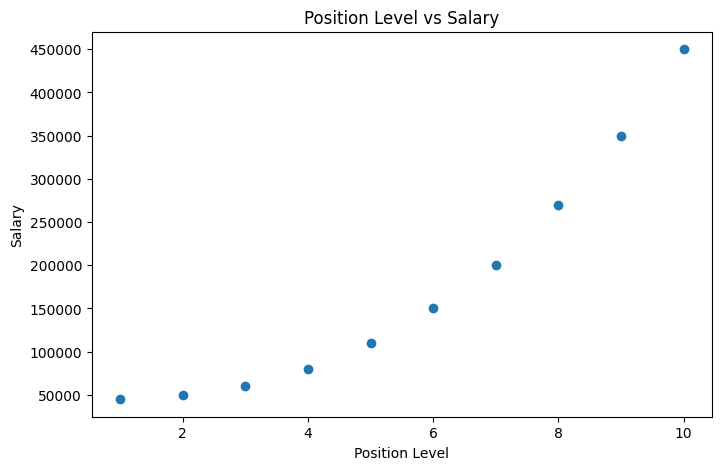

In [5]:
plt.figure(figsize=(8, 5))

plt.scatter(X, y)

plt.xlabel("Position Level")
plt.ylabel("Salary")
plt.title("Position Level vs Salary")

plt.show()

In [6]:
linear_model = LinearRegression()

linear_model.fit(X, y)

y_linear_pred = linear_model.predict(X)

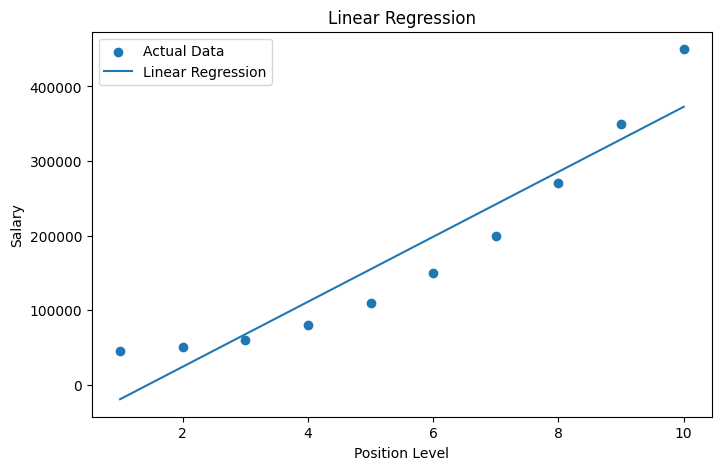

In [7]:
plt.figure(figsize=(8, 5))

plt.scatter(X, y, label="Actual Data")

plt.plot(
    X,
    y_linear_pred,
    label="Linear Regression"
)

plt.xlabel("Position Level")
plt.ylabel("Salary")
plt.title("Linear Regression")

plt.legend()
plt.show()

In [8]:
poly = PolynomialFeatures(degree=2)

X_poly = poly.fit_transform(X)

print("Original X:")
print(X)

print("\nPolynomial X:")
print(X_poly)

Original X:
[[ 1]
 [ 2]
 [ 3]
 [ 4]
 [ 5]
 [ 6]
 [ 7]
 [ 8]
 [ 9]
 [10]]

Polynomial X:
[[  1.   1.   1.]
 [  1.   2.   4.]
 [  1.   3.   9.]
 [  1.   4.  16.]
 [  1.   5.  25.]
 [  1.   6.  36.]
 [  1.   7.  49.]
 [  1.   8.  64.]
 [  1.   9.  81.]
 [  1.  10. 100.]]


In [9]:
poly_model = LinearRegression()

poly_model.fit(X_poly, y)

LinearRegression()

In [10]:
y_poly_pred = poly_model.predict(X_poly)

print("Predicted Salaries:")
print(y_poly_pred)

Predicted Salaries:
[ 51181.81818182  47515.15151515  55666.66666667  75636.36363636
 107424.24242424 151030.3030303  206454.54545455 273696.96969697
 352757.57575758 443636.36363636]


In [11]:
comparison = pd.DataFrame({
    "Position Level": X.flatten(),
    "Actual Salary": y,
    "Predicted Salary": y_poly_pred
})

comparison

,Position Level,Actual Salary,Predicted Salary
0,1,45000,51181.818182
1,2,50000,47515.151515
2,3,60000,55666.666667
3,4,80000,75636.363636
4,5,110000,107424.242424
5,6,150000,151030.303030
6,7,200000,206454.545455
7,8,270000,273696.969697
8,9,350000,352757.575758
9,10,450000,443636.363636


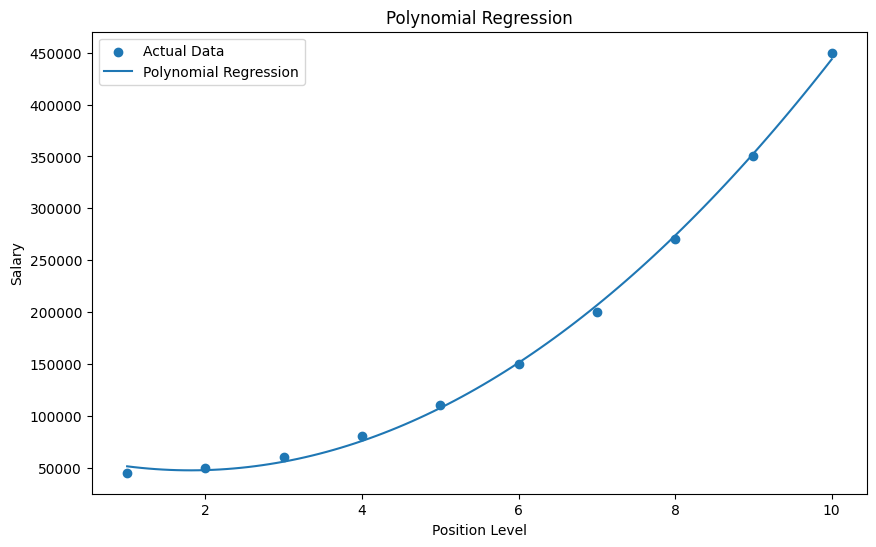

In [12]:
X_smooth = np.linspace(
    X.min(),
    X.max(),
    100
).reshape(-1, 1)

X_smooth_poly = poly.transform(X_smooth)

y_smooth_pred = poly_model.predict(X_smooth_poly)

plt.figure(figsize=(10, 6))

plt.scatter(
    X,
    y,
    label="Actual Data"
)

plt.plot(
    X_smooth,
    y_smooth_pred,
    label="Polynomial Regression"
)

plt.xlabel("Position Level")
plt.ylabel("Salary")
plt.title("Polynomial Regression")

plt.legend()
plt.show()

In [13]:
print("Intercept:", poly_model.intercept_)

print("\nCoefficients:")
print(poly_model.coef_)

Intercept: 66666.66666666669

Coefficients:
[     0.         -21393.93939394   5909.09090909]
